In [1]:
import json
import os
import cv2 as cv
import numpy as np
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset,  DataLoader, random_split
import torch.nn as nn
from torchvision.models import resnet18

In [2]:
COUNT_SCALE = 20.0

class CountingDataset(Dataset):
    def __init__(self, json_path, image_root, transform=None):
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        self.image_root = image_root
        self.transform = transform

        # Images indexed by id
        self.images = {img["id"]: img for img in data["images"]}

        # Collect bboxes per image
        self.bboxes = {}
        for ann in data["annotations"]:
            img_id = ann["image_id"]
            bbox = ann["bbox"]  # [x, y, w, h]
            self.bboxes.setdefault(img_id, []).append(bbox)

        self.image_ids = list(self.images.keys())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.images[img_id]

        img_path = os.path.join(self.image_root, img_info["path"])
        image = cv.imread(img_path, cv.IMREAD_COLOR)

        if image is None:
            raise FileNotFoundError(f"Could not read image: {img_path}")

        # BGR → RGB
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

        # To torch tensor (C, H, W)
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        if self.transform is not None:
            image = self.transform(image)

        # Bounding boxes (N, 4)
        boxes = self.bboxes.get(img_id, [])
        boxes = torch.tensor(boxes, dtype=torch.float32)

        # Count = number of boxes
        count = torch.tensor(len(boxes), dtype=torch.float32)

        return image, count / COUNT_SCALE, boxes

def counting_collate_fn(batch):
    images, counts, boxes = zip(*batch)

    images = torch.stack(images, dim=0)        # (B, 3, H, W)
    counts = torch.stack(counts, dim=0)        # (B,)
    boxes = list(boxes)                         # list of (Ni, 4)

    return images, counts, boxes


20.93137238832081


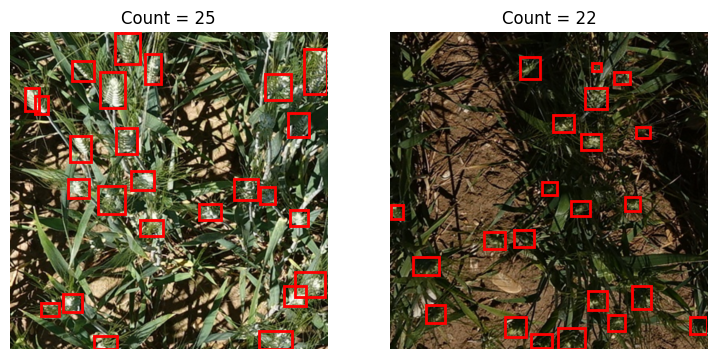

In [5]:
json_path = "data/global-wheat-codalab-official/arvalis_2.json"
image_root = "data/global-wheat-codalab-official"

dataset = CountingDataset(json_path, image_root)

# nums = [num[1].item() * COUNT_SCALE for num in dataset]
# print(np.mean(nums))

# Pick any 3 samples (random or fixed)
indices = [0, 11]

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
#fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))

for ax, idx in zip(axes, indices):
    image, count, boxes = dataset[idx]

    img = image.permute(1, 2, 0).numpy()
    ax.imshow(img)

    for x, y, w, h in boxes:
        ax.add_patch(
            plt.Rectangle(
                (x, y), w, h,
                fill=False,
                edgecolor="red",
                linewidth=2
            )
        )

    ax.set_title(f"Count = {int(count.item() * COUNT_SCALE)}")
    ax.axis("off")

plt.tight_layout()
fig_name = "regression_wheat_examples"
plt.savefig(f"temp/{fig_name}.jpg", dpi=500, bbox_inches='tight', pad_inches=0)
plt.savefig(f"temp/{fig_name}.svg", format="svg", bbox_inches="tight")
plt.show()

In [7]:
class ResNet18Regressor(nn.Module):
    def __init__(self):
        super().__init__()

        # Backbone
        self.backbone = resnet18()

        # Replace classification head with regression head
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)
        # self.backbone.fc = nn.Sequential(
        #     nn.Linear(C, 128),
        #     nn.ReLU(),
        #     nn.Linear(128, 1)
        # )
    

    def forward(self, x):
        x = self.backbone(x)
        return x.squeeze(-1)  # (B,)

# Sanity test
model = ResNet18Regressor()
x = torch.randn(4, 3, 1024, 1024)
with torch.no_grad():
    y = model(x)
print("Input shape :", x.shape)
print("Output shape:", y.shape)
print("Output:", y)

Input shape : torch.Size([4, 3, 1024, 1024])
Output shape: torch.Size([4])
Output: tensor([-0.0368, -0.0649, -0.0576, -0.0408])


In [8]:
def train_regression_model(
    model,
    dataset,
    epochs=10,
    batch_size=8,
    lr=1e-4,
    seed=42,
    device="cpu"
):
    # ------------------------------------------------------------------
    # Reproducibility
    # ------------------------------------------------------------------
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # ------------------------------------------------------------------
    # Train / val split (80 / 20)
    # ------------------------------------------------------------------
    n_total = len(dataset)
    n_train = int(0.8 * n_total)
    n_val = n_total - n_train

    train_set, val_set = random_split(
        dataset,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(seed)
    )

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=counting_collate_fn
    )
    
    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=counting_collate_fn
    )
    # ------------------------------------------------------------------
    # Setup
    # ------------------------------------------------------------------
    model = model.to(device)
    criterion = nn.L1Loss()          # MAE loss (good for counting)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mae": []
    }

    # ------------------------------------------------------------------
    # Training loop
    # ------------------------------------------------------------------
    for epoch in range(1, epochs + 1):
        # ---- Train ----------------------------------------------------
        model.train()
        train_loss = 0.0

        for images, counts, _ in train_loader:
            images = images.to(device)
            counts = counts.to(device)

            optimizer.zero_grad()
            preds = model(images)
            loss = criterion(preds, counts)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)

        # ---- Validation ----------------------------------------------
        model.eval()
        val_loss = 0.0
        val_mae = 0.0

        with torch.no_grad():
            for images, counts, _ in val_loader:
                images = images.to(device)
                counts = counts.to(device)

                preds = model(images)
                loss = criterion(preds, counts)

                val_loss += loss.item() * images.size(0)

                preds_decoded = preds * COUNT_SCALE
                counts_decoded = counts * COUNT_SCALE
                val_mae += torch.abs(preds_decoded - counts_decoded).sum().item()
        

        val_loss /= len(val_loader.dataset)
        val_mae /= len(val_loader.dataset)

        # ---- Logging --------------------------------------------------
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)

        print(
            f"Epoch {epoch:03d} | "
            f"Train L1: {train_loss:.4f} | "
            f"Val L1: {val_loss:.4f} | "
            f"Val MAE: {val_mae:.4f}"
        )

    # ------------------------------------------------------------------
    # Plot losses
    # ------------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train L1")
    plt.plot(history["val_loss"], label="Val L1")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return history

In [52]:
model = ResNet18Regressor()

history = train_regression_model(
    model=model,
    dataset=dataset,
    epochs=20,
    batch_size=4,
    lr=1e-4,
    device="cuda"  # or "cpu"
)

Epoch 001 | Train L1: 16.6561 | Val L1: 15.3918 | Val MAE: 307.8355
Epoch 002 | Train L1: 11.7544 | Val L1: 12.8381 | Val MAE: 256.7615
Epoch 003 | Train L1: 8.9224 | Val L1: 9.7989 | Val MAE: 195.9777
Epoch 004 | Train L1: 6.6966 | Val L1: 8.5554 | Val MAE: 171.1080
Epoch 005 | Train L1: 5.2659 | Val L1: 7.3598 | Val MAE: 147.1953
Epoch 006 | Train L1: 4.4958 | Val L1: 5.7872 | Val MAE: 115.7434
Epoch 007 | Train L1: 4.0581 | Val L1: 6.1642 | Val MAE: 123.2840
Epoch 008 | Train L1: 3.9598 | Val L1: 5.2065 | Val MAE: 104.1293
Epoch 009 | Train L1: 3.8407 | Val L1: 12.2454 | Val MAE: 244.9086


KeyboardInterrupt: 